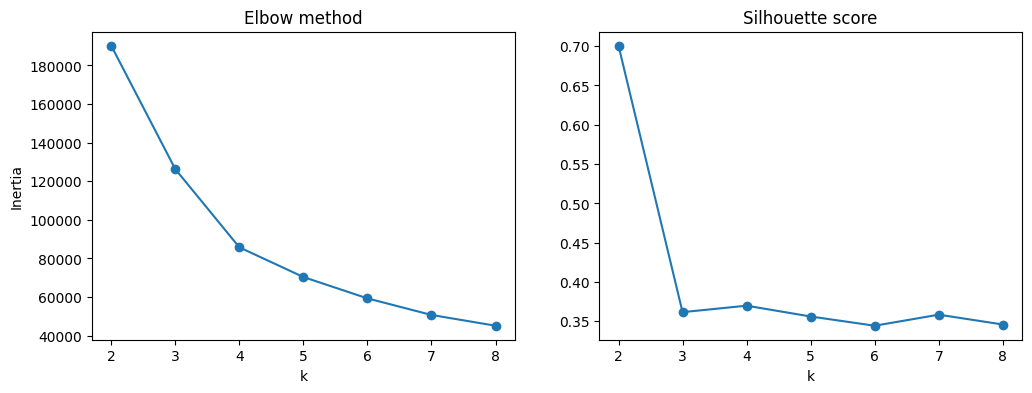

{2: np.float64(0.701), 3: np.float64(0.362), 4: np.float64(0.37), 5: np.float64(0.356), 6: np.float64(0.344), 7: np.float64(0.358), 8: np.float64(0.346)}


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load data (Colab may store the uploaded file in / or /content)
path = '/final_customer_segments.csv' if os.path.exists('/final_customer_segments.csv') else 'final_customer_segments.csv'
df = pd.read_csv(path)

# 2. Log-transform skewed features, then scale
X = df[['Recency', 'Frequency', 'Monetary']].copy()
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])
X_scaled = StandardScaler().fit_transform(X)

# 3. Choose k: elbow (inertia) and silhouette score
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertias, marker='o'); ax[0].set_title('Elbow method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(ks, sils, marker='o'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.show()

print(dict(zip(ks, np.round(sils, 3))))

In [7]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

profile = df.groupby('Cluster').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency_days=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean'),
    median_monetary=('Monetary', 'median')
).round(1)
profile['share_%'] = (profile['customers'] / len(df) * 100).round(1)
profile

,customers,avg_recency_days,avg_frequency,avg_monetary,median_monetary,share_%
Cluster,,,,,,
0,35690,147.8,1.0,69.1,66.0,38.2
1,27010,425.4,1.0,119.5,98.2,28.9
2,2801,220.3,2.1,308.6,225.6,3.0
3,27856,173.5,1.0,318.2,210.4,29.8


In [8]:
names = {0: 'Recent low spenders', 1: 'Lapsed one-timers',
         2: 'Repeat buyers', 3: 'High-value one-timers'}

df['Cluster_Name'] = df['Cluster'].map(names)
profile['name'] = pd.Series(names)
profile['revenue_share_%'] = (df.groupby('Cluster')['Monetary'].sum()
                              / df['Monetary'].sum() * 100).round(1)
profile

,customers,avg_recency_days,avg_frequency,avg_monetary,median_monetary,share_%,name,revenue_share_%
Cluster,,,,,,,,
0,35690,147.8,1.0,69.1,66.0,38.2,Recent low spenders,16.0
1,27010,425.4,1.0,119.5,98.2,28.9,Lapsed one-timers,20.9
2,2801,220.3,2.1,308.6,225.6,3.0,Repeat buyers,5.6
3,27856,173.5,1.0,318.2,210.4,29.8,High-value one-timers,57.5


## K-Means customer clusters (k = 4)

Features: Recency, log(Frequency), log(Monetary), standardized.
k = 4 was chosen using the elbow method (clear bend at 4) and silhouette score
(best among k = 3 to 8).

| Cluster | Customers | Revenue | Profile |
|---|---|---|---|
| Recent low spenders | 38.2% | 16.0% | ~148 days since purchase, avg spend 69 |
| Lapsed one-timers | 28.9% | 20.9% | ~425 days since purchase, avg spend 120 |
| Repeat buyers | 3.0% | 5.6% | 2.1 orders on average, avg spend 309 |
| High-value one-timers | 29.8% | 57.5% | ~174 days since purchase, avg spend 318 |

**Key finding:** High-value one-timers are 30% of customers but generate 57.5% of
revenue. Only 3% of customers buy more than once.

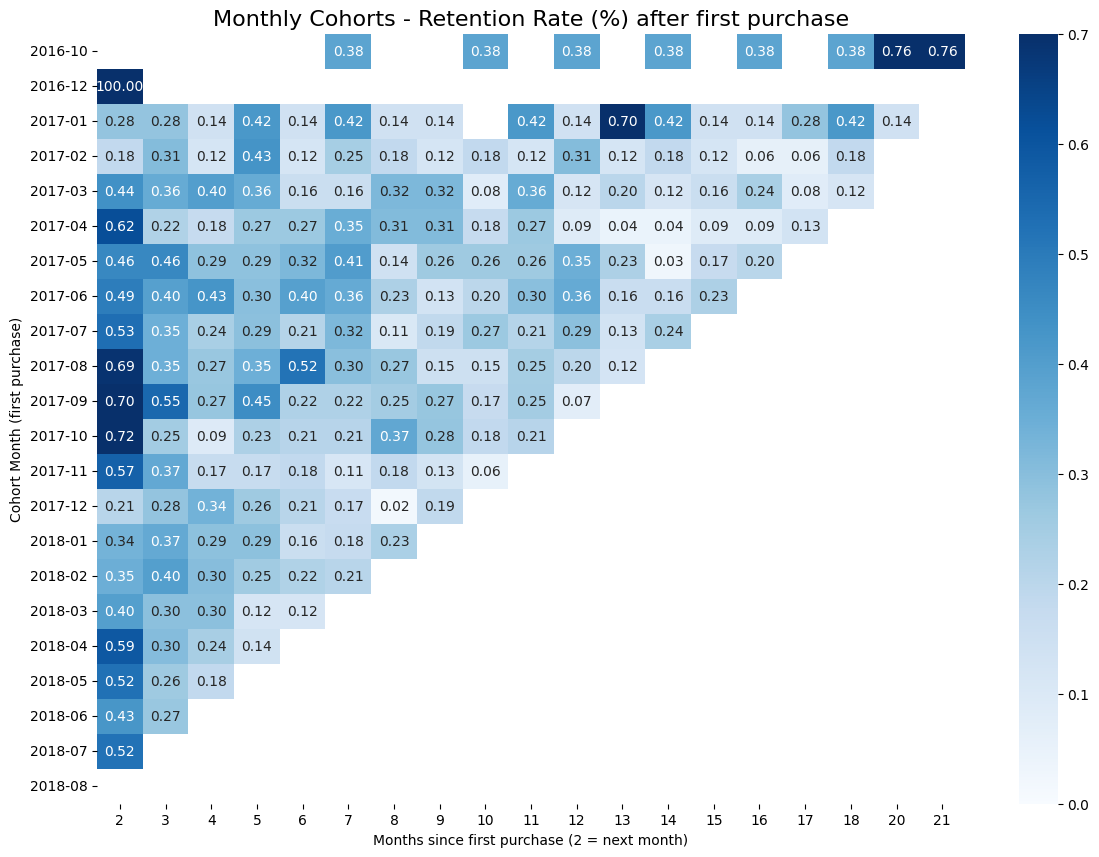

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = '/rfm_data.csv' if os.path.exists('/rfm_data.csv') else 'rfm_data.csv'
raw_df = pd.read_csv(path)
raw_df['order_purchase_timestamp'] = pd.to_datetime(raw_df['order_purchase_timestamp'])

raw_df['order_month'] = raw_df['order_purchase_timestamp'].dt.to_period('M')
raw_df['cohort'] = raw_df.groupby('customer_unique_id')['order_month'].transform('min')

raw_df['cohort_index'] = (
    (raw_df['order_month'].dt.year - raw_df['cohort'].dt.year) * 12
    + (raw_df['order_month'].dt.month - raw_df['cohort'].dt.month) + 1
)

cohort_data = raw_df.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_unique_id')
retention_matrix = cohort_matrix.divide(cohort_matrix.iloc[:, 0], axis=0) * 100

plt.figure(figsize=(14, 10))
plt.title('Monthly Cohorts - Retention Rate (%) after first purchase', fontsize=16)
sns.heatmap(retention_matrix.iloc[:, 1:], annot=True, fmt='.2f',
            cmap='Blues', vmin=0, vmax=0.7)
plt.ylabel('Cohort Month (first purchase)')
plt.xlabel('Months since first purchase (2 = next month)')
plt.show()